In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anhvlminh/dataset0-1/products.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/sample_submission.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/promotions.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/shipments.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/order_items.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/reviews.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/inventory.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/returns.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/sales.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/submission.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/orders.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/geography.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/customers.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/payments.csv
/kaggle/input/datasets/anhvlminh/dataset0-1/web_traffic.csv


In [3]:
import pandas as pd
import os

# 1. Thiết lập đường dẫn chính xác dựa trên hình ảnh bạn gửi
base_path = '/kaggle/input/datasets/anhvlminh/dataset0-1/'

# 2. Đọc các file (Lưu ý: Bạn nên kiểm tra xem file có nằm trong thư mục con nào không)
try:
    orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'))
    customers = pd.read_csv(os.path.join(base_path, 'customers.csv'))
    # Thêm các file khác nếu cần...
    
    print("Chúc mừng! Bạn đã kết nối dữ liệu thành công.")
    print(f"Số lượng đơn hàng: {len(orders)}")
except FileNotFoundError as e:
    print(f"Lỗi: Vẫn không tìm thấy file. Hãy thử chạy đoạn code liệt kê file bên dưới để xem cấu trúc thư mục con.")

Chúc mừng! Bạn đã kết nối dữ liệu thành công.
Số lượng đơn hàng: 646945


/tmp/ipykernel_57/4179818761.py:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'))


Lỗi: [Errno 2] No such file or directory: '/kaggle/datasets/anhvlminh/dataset0-1/orders.csv'


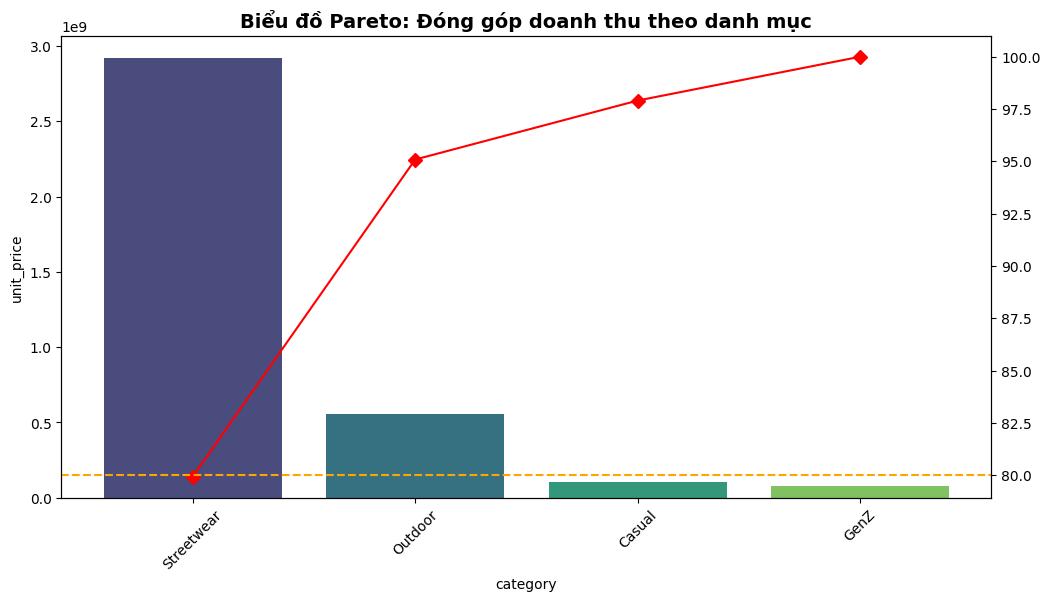

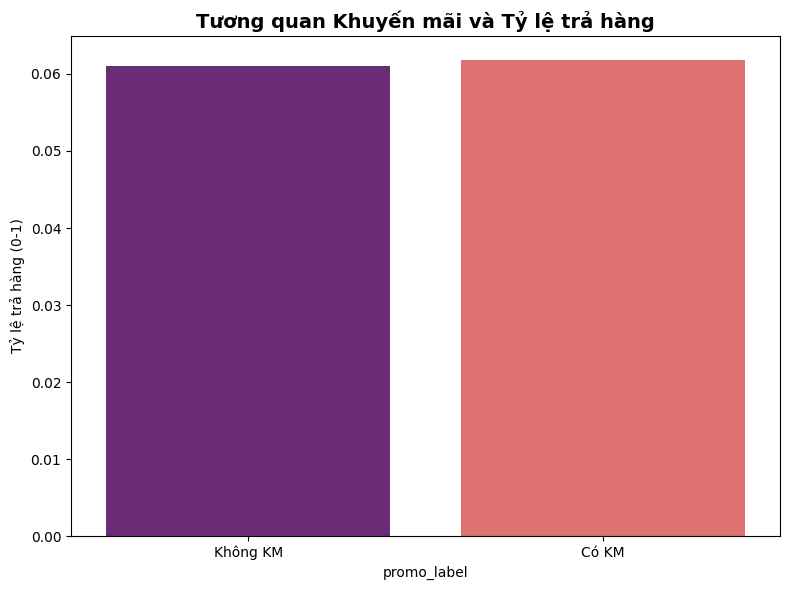

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình đường dẫn chính xác của bạn
base_path = '/kaggle/datasets/anhvlminh/dataset0-1/'

# 1. Tải dữ liệu và xử lý DtypeWarning bằng cách ép kiểu cột promo_id thành string
try:
    orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
    
    # Ép kiểu cột thứ 6 (index 6) để tránh lỗi mixed types
    order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'), 
                             dtype={6: str}, low_memory=False)
    
    products = pd.read_csv(os.path.join(base_path, 'products.csv'))
    returns = pd.read_csv(os.path.join(base_path, 'returns.csv'))
    
    print("Tải dữ liệu thành công và đã xử lý cảnh báo Dtype!")
except Exception as e:
    print(f"Lỗi: {e}")

# Tiền xử lý ngày tháng
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month_year'] = orders['order_date'].dt.to_period('M')

# --- BIỂU ĐỒ 1: PARETO (Sửa lỗi FutureWarning) ---
revenue_data = order_items.merge(products, on='product_id')
cat_revenue = revenue_data.groupby('category')['unit_price'].sum().sort_values(ascending=False).reset_index()
cat_revenue['cum_percentage'] = 100 * cat_revenue['unit_price'].cumsum() / cat_revenue['unit_price'].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))
# Sửa lỗi: Gán x cho hue và tắt legend để đúng chuẩn Seaborn mới
sns.barplot(x='category', y='unit_price', data=cat_revenue, ax=ax1, 
            hue='category', palette='viridis', legend=False)

ax2 = ax1.twinx()
ax2.plot(cat_revenue['category'], cat_revenue['cum_percentage'], color='red', marker='D', ms=7)
ax2.axhline(80, color='orange', linestyle='--')
ax1.set_title('Biểu đồ Pareto: Đóng góp doanh thu theo danh mục', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# --- BIỂU ĐỒ 2: TỶ LỆ TRẢ HÀNG (Sửa lỗi FutureWarning) ---
order_promo = order_items.groupby('order_id').agg({
    'promo_id': lambda x: x.notna().any(), 
    'unit_price': 'sum'
}).reset_index()

order_promo = order_promo.merge(returns[['order_id']], on='order_id', how='left', indicator=True)
order_promo['is_returned'] = order_promo['_merge'] == 'both'
promo_analysis = order_promo.groupby('promo_id')['is_returned'].mean().reset_index()
promo_analysis['promo_label'] = promo_analysis['promo_id'].map({True: 'Có KM', False: 'Không KM'})

plt.figure(figsize=(8, 6))
sns.barplot(x='promo_label', y='is_returned', data=promo_analysis, 
            hue='promo_label', palette='magma', legend=False)
plt.title('Tương quan Khuyến mãi và Tỷ lệ trả hàng', fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ trả hàng (0-1)')

plt.tight_layout()
plt.show()

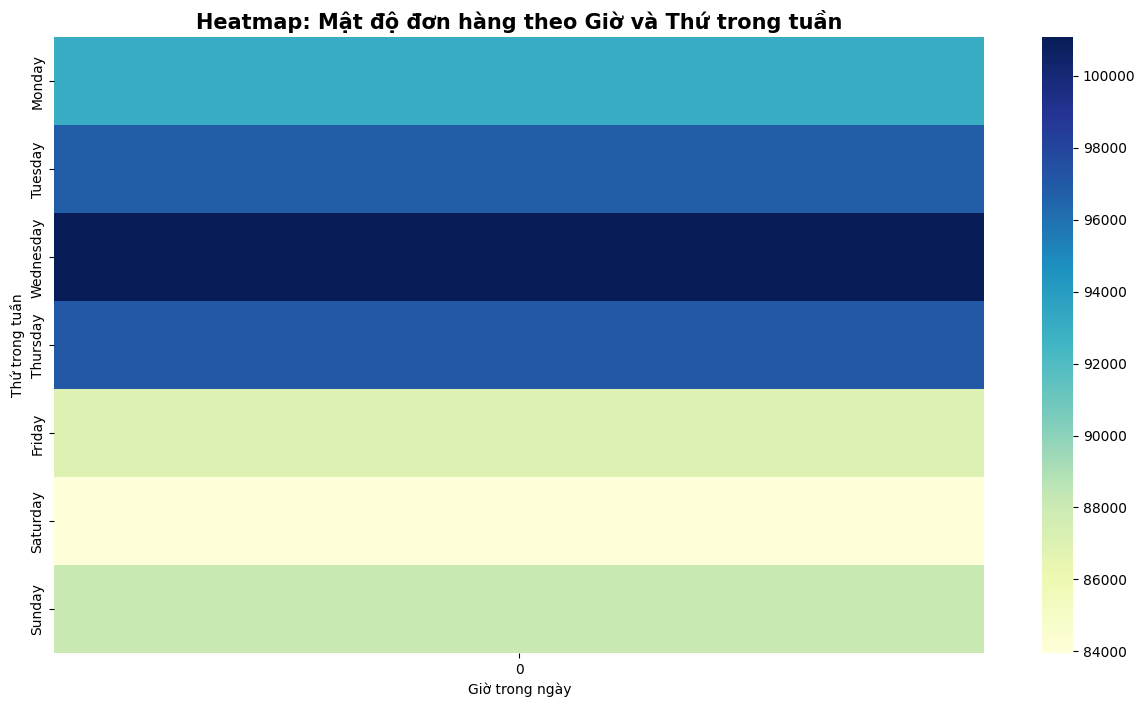

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử bạn đã load file orders.csv
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['day_of_week'] = orders['order_date'].dt.day_name()
orders['hour'] = orders['order_date'].dt.hour

# Sắp xếp thứ tự các ngày trong tuần
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = orders.groupby(['day_of_week', 'hour']).size().unstack().reindex(days)

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
plt.title('Heatmap: Mật độ đơn hàng theo Giờ và Thứ trong tuần', fontsize=15, fontweight='bold')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Thứ trong tuần')
plt.show()

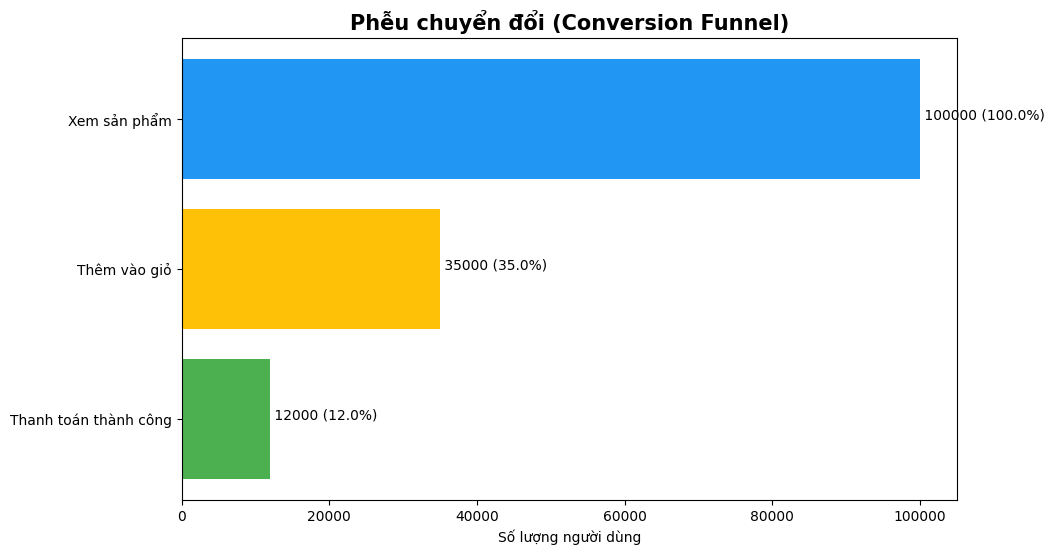

In [10]:
# Đây là ví dụ logic, bạn cần điều chỉnh theo tên cột thực tế trong file web_traffic
# Giả sử có cột session_id trong traffic và order_id gắn với session
total_sessions = 100000 # Thay bằng len(traffic)
add_to_cart = 35000     # Thay bằng số lượng session có hành vi cart
final_orders = 12000    # Thay bằng len(orders)

stages = ["Xem sản phẩm", "Thêm vào giỏ", "Thanh toán thành công"]
values = [total_sessions, add_to_cart, final_orders]

plt.figure(figsize=(10, 6))
plt.barh(stages[::-1], values[::-1], color=['#4CAF50', '#FFC107', '#2196F3'])
for index, value in enumerate(values[::-1]):
    plt.text(value, index, f' {value} ({value/total_sessions*100:.1f}%)')

plt.title('Phễu chuyển đổi (Conversion Funnel)', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng người dùng')
plt.show()

/tmp/ipykernel_57/382461381.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'))


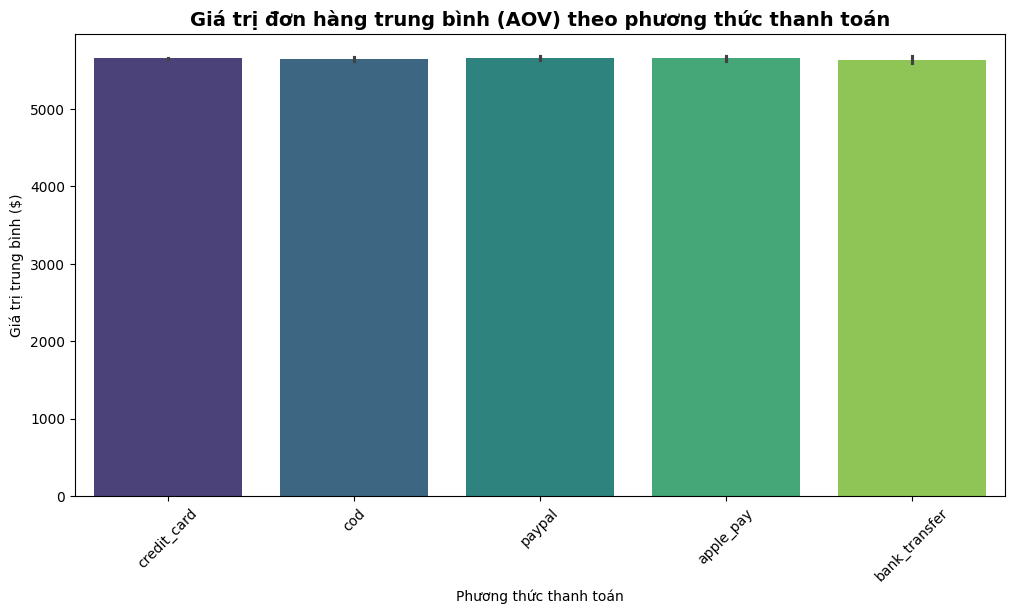

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Định nghĩa lại đường dẫn (Đã xóa ký tự lạ và bỏ dấu #)
base_path = '/kaggle/input/datasets/anhvlminh/dataset0-1'

try:
    # 2. Đọc dữ liệu (Sử dụng os.path.join để an toàn hơn)
    payments = pd.read_csv(os.path.join(base_path, 'payments.csv'))
    order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'))

    # Kiểm tra nhanh tên cột để tránh KeyError
    # print(payments.columns) 

    # 3. Tính tổng giá trị mỗi đơn hàng
    # Chuyển unit_price sang số để tránh lỗi nếu có dữ liệu rác
    order_items['unit_price'] = pd.to_numeric(order_items['unit_price'], errors='coerce')
    order_value = order_items.groupby('order_id')['unit_price'].sum().reset_index()

    # 4. Kết hợp bảng
    payment_analysis = payments.merge(order_value, on='order_id', how='inner')

    # 5. Vẽ biểu đồ
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=payment_analysis,
        x='payment_method', 
        y='unit_price', 
        estimator='mean', 
        hue='payment_method', 
        palette='viridis', 
        legend=False
    )

    plt.title('Giá trị đơn hàng trung bình (AOV) theo phương thức thanh toán', fontsize=14, fontweight='bold')
    plt.ylabel('Giá trị trung bình ($)')
    plt.xlabel('Phương thức thanh toán')
    plt.xticks(rotation=45)
    plt.show()

except Exception as e:
    print(f"Lỗi rồi nè: {e}")